# Score Visualization for sunflow-scores

This notebook loads validation outputs (mae/rmse, kt, by-hour) and generates:
- Lead-time error curves
- Diurnal cycle plots (hour-of-day)
- Optional spatial subsetting

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("../results")
run_tag = None  # set to "20250101_20250103" or None to auto-latest

In [2]:
def _matches_metric(name, p: Path):
    stem = p.stem
    if stem == name:
        return True
    if not stem.startswith(f"{name}_"):
        return False

    tail = stem[len(name) + 1 :]
    # Exclude submetrics with _kt or _by_init when calling base metrics.
    if tail.startswith("kt") or tail.startswith("by_init"):
        return False
    return True


def pick_score_path(name):
    if run_tag:
        candidate = results_dir / f"{name}_{run_tag}.nc"
        if candidate.exists():
            return candidate
        raise FileNotFoundError(candidate)

    candidate_paths = sorted(results_dir.glob(f"{name}_*.nc"))
    candidate_paths = [p for p in candidate_paths if _matches_metric(name, p)]
    if not candidate_paths:
        exact = results_dir / f"{name}.nc"
        if exact.exists():
            return exact
        raise FileNotFoundError(f"No metric file found for {name} in {results_dir}")
    return candidate_paths[-1]

# Prefer target names from run_dir if tag unknown; variants will be discovered dynamically.
score_names = [
    "mae", "rmse",
    "mae_kt", "rmse_kt",
    "mae_by_init", "rmse_by_init",
    "mae_kt_by_init", "rmse_kt_by_init",
]

scores = {}
for name in score_names:
    try:
        scores[name] = xr.open_dataarray(pick_score_path(name))
    except FileNotFoundError:
        print(f"Warning: {name} not found in {results_dir}")

for k, v in list(scores.items()):
    if "lead_time" in v.coords:
        scores[k] = v.assign_coords(lead_time=pd.to_timedelta(v.coords["lead_time"].values, unit="min"))

In [3]:
print('Loaded score variables:', list(scores.keys()))
if scores:
    sample = next(iter(scores.values()))
    print(sample)

Loaded score variables: ['mae', 'rmse', 'mae_kt', 'rmse_kt', 'mae_by_init', 'rmse_by_init', 'mae_kt_by_init', 'rmse_kt_by_init']
<xarray.DataArray 'mae_by_hour' (lat: 368, lon: 713, hour: 13)> Size: 27MB
[3410992 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 3kB 63.48 63.43 63.39 63.35 ... 47.36 47.32 47.27
  * lon      (lon) float64 6kB -10.73 -10.69 -10.64 -10.6 ... 19.89 19.94 19.98
  * hour     (hour) int64 104B 8 9 10 11 12 13 14 15 16 17 18 19 20
Attributes:
    description:  Probabilistic advection solar forecast
    long_name:    Surface downwelling solar radiation
    units:        W m-2


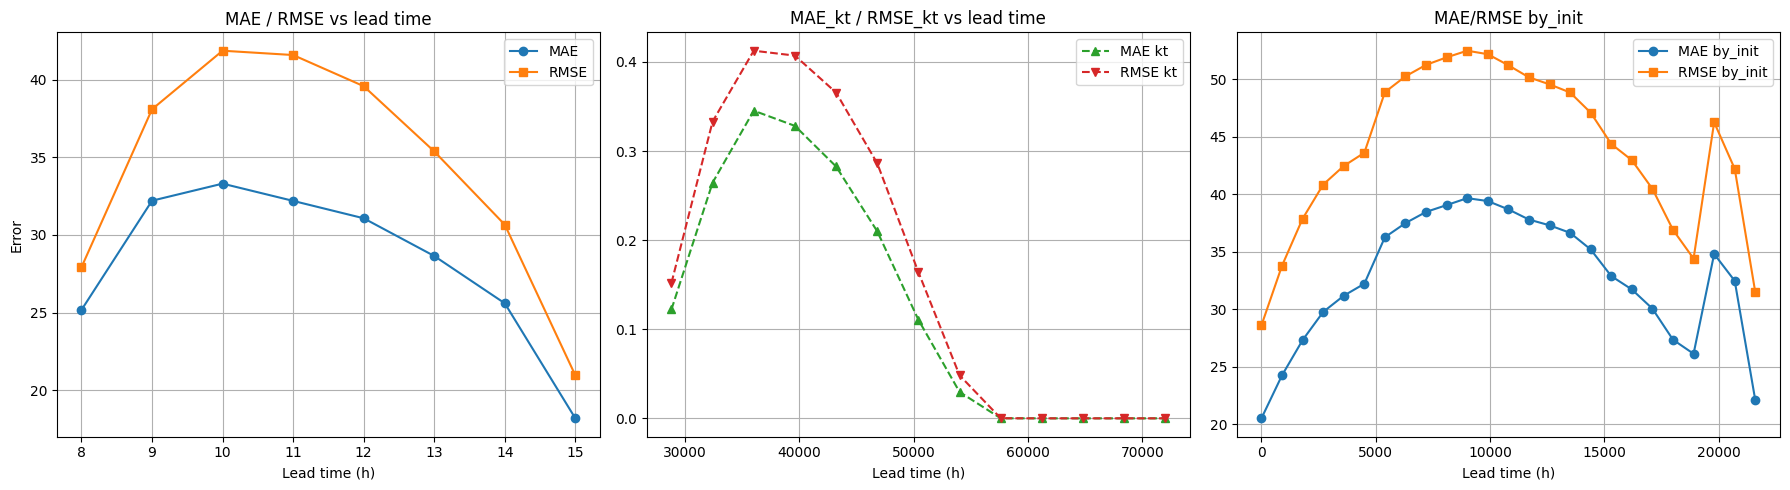

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

# left axis (MAE/RMSE)
if "mae" in scores and "rmse" in scores:
    mae_coord = "lead_time" if "lead_time" in scores["mae"].coords else ("hour" if "hour" in scores["mae"].coords else None)
    if mae_coord is None:
        raise KeyError(f"'mae' has neither 'lead_time' nor 'hour' coordinates. Available: {list(scores['mae'].coords)}")

    if mae_coord == "lead_time":
        x_mae = scores["mae"].coords["lead_time"].astype("timedelta64[m]").astype(int) 
    else:
        x_mae = scores["mae"].coords["hour"].astype(float)
    rmse_coord = "lead_time" if "lead_time" in scores["rmse"].coords else ("hour" if "hour" in scores["rmse"].coords else None)
    if rmse_coord is None:
        raise KeyError(f"'rmse' has neither 'lead_time' nor 'hour' coordinates. Available: {list(scores['rmse'].coords)}")

    if rmse_coord == "lead_time":
        x_rmse = scores["rmse"].coords["lead_time"].astype("timedelta64[m]").astype(int) 
    else:
        x_rmse = scores["rmse"].coords["hour"].astype(float)
    base_mae = scores["mae"].mean(dim=[d for d in ["lat", "lon"] if d in scores["mae"].dims]).values
    base_rmse = scores["rmse"].mean(dim=[d for d in ["lat", "lon"] if d in scores["rmse"].dims]).values
    # Ensure y-series are 1D (lead_time) to match x
    if np.ndim(base_mae) > 1:
        base_mae = np.nanmean(base_mae, axis=tuple(range(np.ndim(base_mae) - 1)))
    if np.ndim(base_rmse) > 1:
        base_rmse = np.nanmean(base_rmse, axis=tuple(range(np.ndim(base_rmse) - 1)))

    axs[0].plot(np.asarray(x_mae), np.asarray(base_mae), marker="o", color="C0", label="MAE")
    axs[0].plot(np.asarray(x_rmse), np.asarray(base_rmse), marker="s", color="C1", label="RMSE")
    axs[0].set_ylabel("Error")
    axs[0].set_xlabel("Lead time (h)")
    axs[0].set_title("MAE / RMSE vs lead time")
    axs[0].grid(True)
    axs[0].legend()
else:
    axs[0].text(0.5, 0.5, "MAE/RMSE not available", ha="center")

# middle axis (MAE_kt/RMSE_kt)
if "mae_kt" in scores and "rmse_kt" in scores:
    for key in ("mae_kt", "rmse_kt"):
        if "lead_time" not in scores[key].coords:
            if "hour" in scores[key].coords:
                scores[key] = scores[key].assign_coords(
                    lead_time=("hour", pd.to_timedelta(scores[key].coords["hour"].values, unit="h"))
                )
            else:
                raise KeyError(
                    f"'{key}' has neither 'lead_time' nor 'hour' coordinates. Available: {list(scores[key].coords)}"
                )

    x_mae_kt = scores["mae_kt"].coords["lead_time"].astype("timedelta64[m]").astype(int) 
    x_rmse_kt = scores["rmse_kt"].coords["lead_time"].astype("timedelta64[m]").astype(int) 
    base_mae_kt = scores["mae_kt"].mean(dim=[d for d in ["lat", "lon"] if d in scores["mae_kt"].dims]).values
    base_rmse_kt = scores["rmse_kt"].mean(dim=[d for d in ["lat", "lon"] if d in scores["rmse_kt"].dims]).values

    if np.ndim(base_mae_kt) > 1:
        base_mae_kt = np.nanmean(base_mae_kt, axis=tuple(range(np.ndim(base_mae_kt) - 1)))
    if np.ndim(base_rmse_kt) > 1:
        base_rmse_kt = np.nanmean(base_rmse_kt, axis=tuple(range(np.ndim(base_rmse_kt) - 1)))

    axs[1].plot(np.asarray(x_mae_kt), np.asarray(base_mae_kt), marker="^", linestyle="--", color="C2", label="MAE kt")
    axs[1].plot(np.asarray(x_rmse_kt), np.asarray(base_rmse_kt), marker="v", linestyle="--", color="C3", label="RMSE kt")
    axs[1].set_xlabel("Lead time (h)")
    axs[1].set_title("MAE_kt / RMSE_kt vs lead time")
    axs[1].grid(True)
    axs[1].legend()
else:
    axs[1].text(0.5, 0.5, "MAE_kt/RMSE_kt not available", ha="center")

# right axis (by_init curve for a sample init, or averaged)
if "mae_by_init" in scores and "rmse_by_init" in scores:
    x_by_init = scores["mae_by_init"].coords["lead_time"].astype("timedelta64[m]").astype(int) 
    m1 = scores["mae_by_init"].mean(dim=[d for d in ["initialization_time"] if d in scores["mae_by_init"].dims]).values
    m2 = scores["rmse_by_init"].mean(dim=[d for d in ["initialization_time"] if d in scores["rmse_by_init"].dims]).values
    if np.ndim(m1) > 1:
        m1 = np.nanmean(m1, axis=tuple(range(np.ndim(m1) - 1)))
    if np.ndim(m2) > 1:
        m2 = np.nanmean(m2, axis=tuple(range(np.ndim(m2) - 1)))
    axs[2].plot(np.asarray(x_by_init), np.asarray(m1), marker="o", label="MAE by_init")
    axs[2].plot(np.asarray(x_by_init), np.asarray(m2), marker="s", label="RMSE by_init")
    axs[2].set_xlabel("Lead time (h)")
    axs[2].set_title("MAE/RMSE by_init")
    axs[2].grid(True)
    axs[2].legend()
else:
    axs[2].text(0.5, 0.5, "By-init metrics not available", ha="center")

plt.tight_layout()
plt.show()

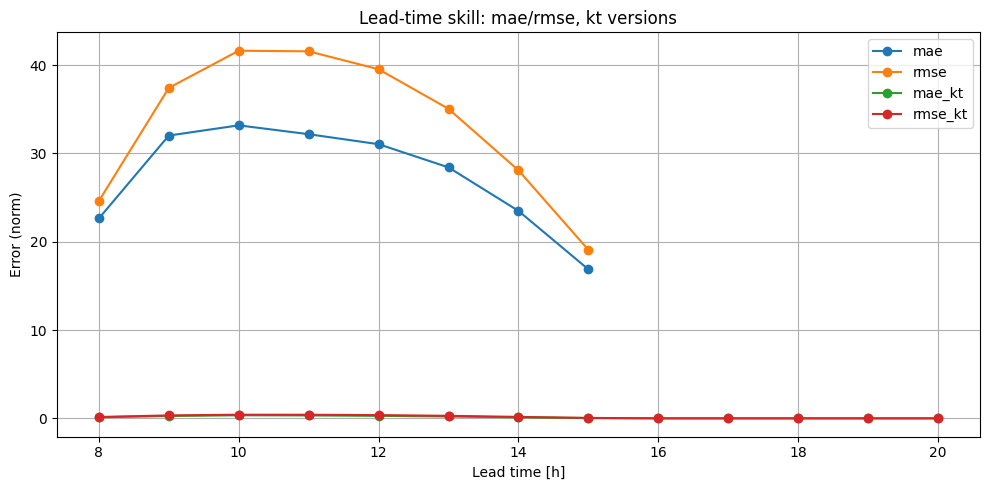

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def lead_h(da):
    if "lead_time" in da.coords:
        lt = da.coords["lead_time"]
        if np.issubdtype(lt.dtype, np.number):
            # minutes as numeric fallback
            lt = pd.to_timedelta(lt.values, unit="m")
    elif "hour" in da.coords:
        lt = pd.to_timedelta(da.coords["hour"].values, unit="h")
    else:
        raise KeyError("DataArray has no lead_time or hour coordinate")

    if np.issubdtype(lt.dtype, np.timedelta64):
        # use division by timedelta to get float hours
        hours = lt / np.timedelta64(1, "h")
        return np.asarray(hours, dtype=float)
    else:
        lt = pd.to_timedelta(lt)
        return lt / np.timedelta64(1, "h")
plt.figure(figsize=(10, 5))
for n,c in [("mae","C0"),("rmse","C1"),("mae_kt","C2"),("rmse_kt","C3")]:
    if n not in scores: continue
    da = scores[n]
    # if spatial dims exist, collapse
    for dim in ["lat","lon","x","y"]:
        if dim in da.dims:
            da = da.mean(dim=dim)
    x = lead_h(da)
    y = da.values
    # if extra lead dim reduction remains:
    if y.ndim > 1:
        y = np.nanmean(y, axis=tuple(range(y.ndim - 1)))
    plt.plot(x, y, marker="o", label=n, color=c)

plt.xlabel("Lead time [h]")
plt.ylabel("Error (norm)")
plt.title("Lead-time skill: mae/rmse, kt versions")
plt.legend()
plt.grid(True)
plt.tight_layout()

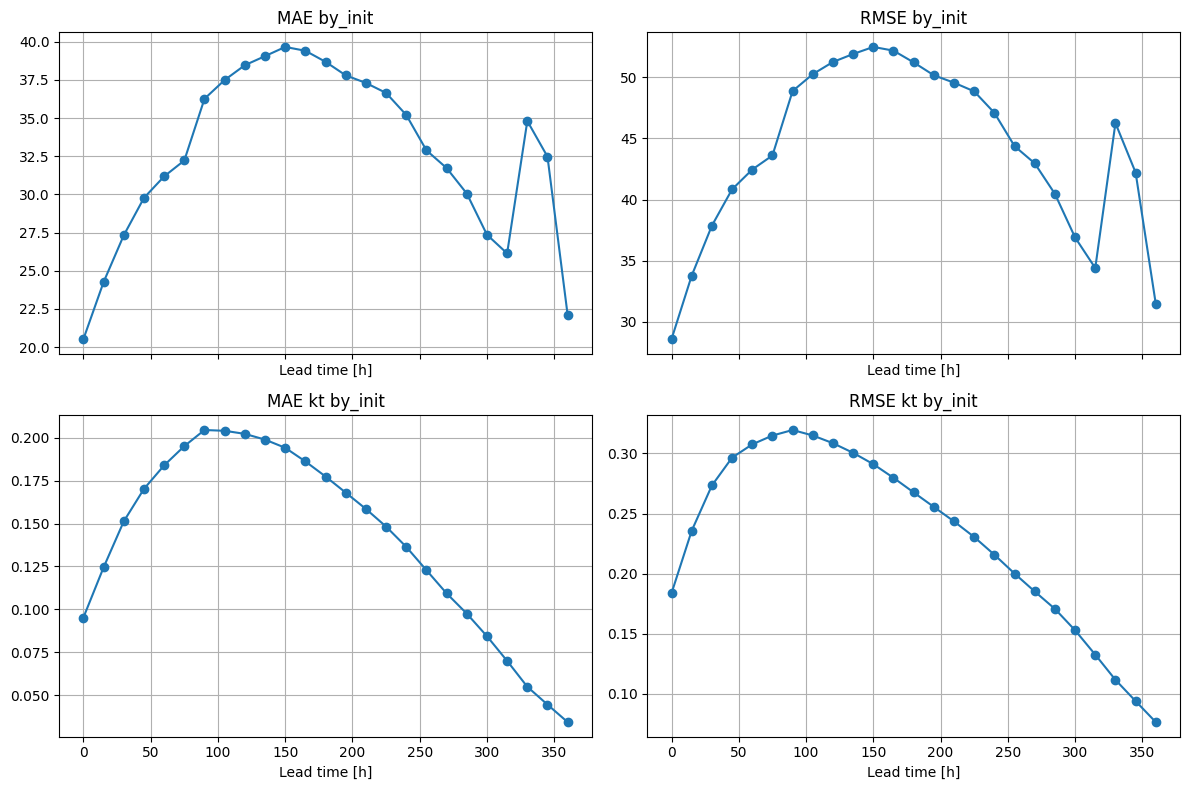

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (n, title) in zip(axs.flat, [
    ("mae_by_init","MAE by_init"),
    ("rmse_by_init","RMSE by_init"),
    ("mae_kt_by_init","MAE kt by_init"),
    ("rmse_kt_by_init","RMSE kt by_init"),
]):
    if n not in scores:
        ax.text(0.5, 0.5, f"{n} missing", ha="center")
        ax.set_title(title)
        continue

    da = scores[n]
    # mean over initialization_time to get lead-time curve
    if "initialization_time" in da.dims:
        y = da.mean(dim="initialization_time")
    else:
        y = da
    x = lead_h(y).values
    y = y.values
    if y.ndim > 1:
        y = np.nanmean(y, axis=tuple(range(y.ndim - 1)))
    ax.plot(x, y, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Lead time [h]")
    ax.grid(True)

plt.tight_layout()

sample init 2025-01-02T08:00:00.000000000


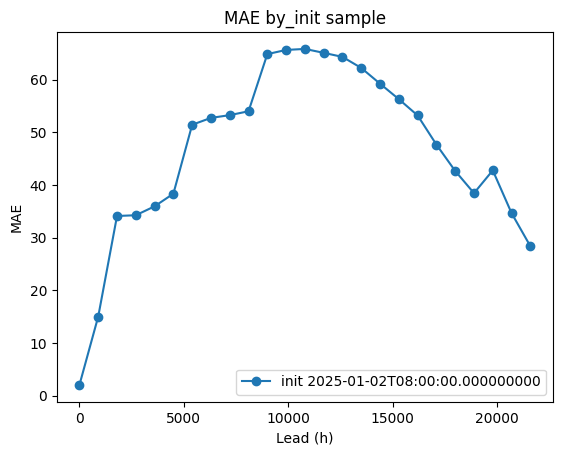

In [27]:
sel_init = scores["mae_by_init"].initialization_time[0]
print("sample init", sel_init.values)
ax = scores["mae_by_init"].sel(initialization_time=sel_init).plot(
    label=f"init {sel_init.values}", marker="o")
# xarray/matplotlib can return a list of Line2D for line plots
if isinstance(ax, list):
    ax = ax[0].axes

ax.set_xlabel("Lead (h)")
ax.set_ylabel("MAE")
ax.set_title("MAE by_init sample")
ax.legend()

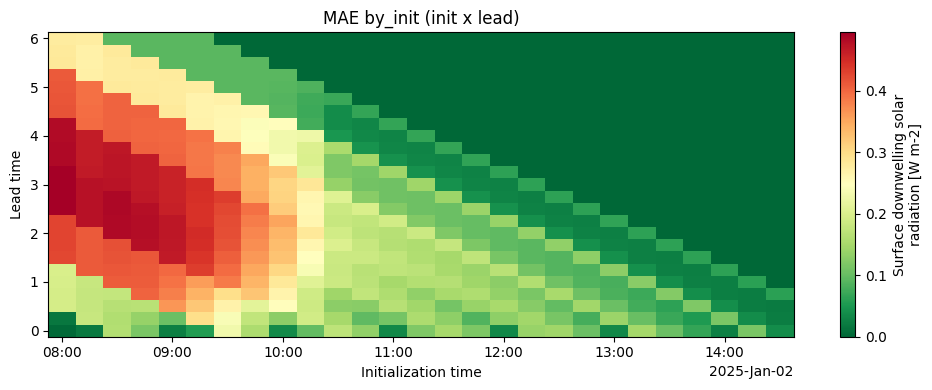

In [23]:
da = scores["mae_kt_by_init"]
if "initialization_time" in da.dims:
    plt.figure(figsize=(10, 4))
    da_plot = da.assign_coords(
        lead_time_h=da["lead_time"] / np.timedelta64(1, "h")
    ).swap_dims({"lead_time": "lead_time_h"})
    da_plot.transpose("lead_time_h", "initialization_time").plot(cmap="RdYlGn_r")
    plt.title("MAE by_init (init x lead)")
    plt.ylabel("Lead time")
    plt.xlabel("Initialization time")
    plt.tight_layout()